In [2]:
import numpy as np
import pandas as pd

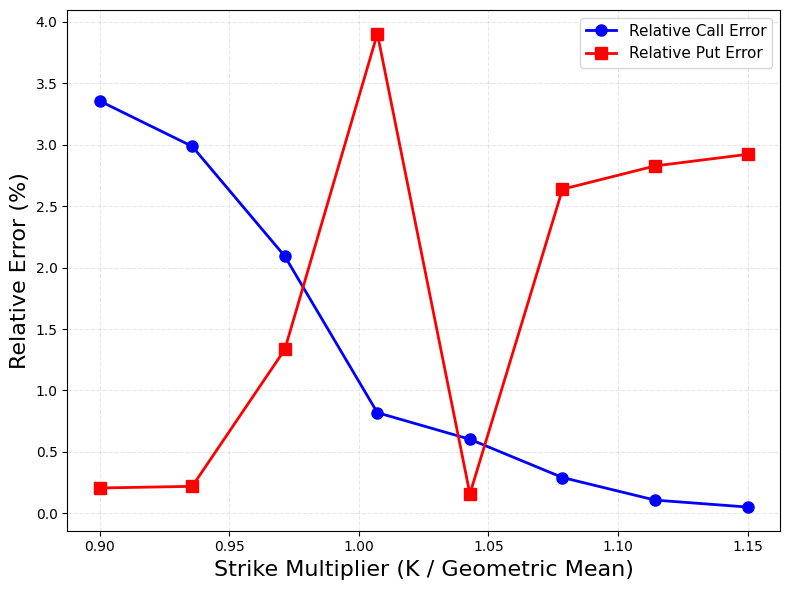

In [11]:
results_df = pd.read_csv("data/moneyness_test.csv", index_col=0)
results_df['call_error'] = np.abs(results_df['glsm_call'] - results_df['BS_call']) / np.abs(results_df['BS_call']) * 100
results_df['put_error'] = np.abs(results_df['glsm_put'] - results_df['bm_put']) / np.abs(results_df['bm_put']) * 100


results_df['call_error_abs'] = np.abs(results_df['glsm_call'] - results_df['BS_call'])
results_df['put_error_abs'] = np.abs(results_df['glsm_put'] - results_df['bm_put'])
results_df
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(results_df['strike_mul'], results_df['call_error_abs'], 'o-', 
    label='Relative Call Error', color='blue', linewidth=2, markersize=8)
ax.plot(results_df['strike_mul'], results_df['put_error_abs'], 's-', 
    label='Relative Put Error', color='red', linewidth=2, markersize=8)


ax.set_xlabel('Strike Multiplier (K / Geometric Mean)', fontsize=16)
ax.set_ylabel('Relative Error (%)', fontsize=16)
# ax.set_title('G-LSM Pricing Error vs Moneyness', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("figures/error_v_moneyness.pdf")


In [15]:
# use numbers from paper to graph the error of LSM and G-LSM vs dimesion

cols = ["d", "Nb", "LSM", "Error", "G-LMS", "Error G", "Exact"]
data = [
    [1, 11, 3.6715, 0.16, 3.6532, 0.34, 3.6658],
    [2, 29, 3.1886, 0.18, 3.1791, 0.12, 3.1831],
    [3, 56, 3.0113, 0.28, 2.9896, 0.44, 3.0029],
    [5, 141, 2.8700, 0.70, 2.8381, 0.41, 2.8499],
    [10, 581, 2.8030, 2.71, 2.7160, 0.48, 2.7290],
    [15, 1446, 2.8258, 5.15, 2.6726, 0.55, 2.6874]
]

table_2_df = pd.DataFrame(data, columns=cols)
table_2_df

,d,Nb,LSM,Error,G-LMS,Error G,Exact
0,1,11,3.6715,0.16,3.6532,0.34,3.6658
1,2,29,3.1886,0.18,3.1791,0.12,3.1831
2,3,56,3.0113,0.28,2.9896,0.44,3.0029
3,5,141,2.8700,0.70,2.8381,0.41,2.8499
4,10,581,2.8030,2.71,2.7160,0.48,2.7290
5,15,1446,2.8258,5.15,2.6726,0.55,2.6874


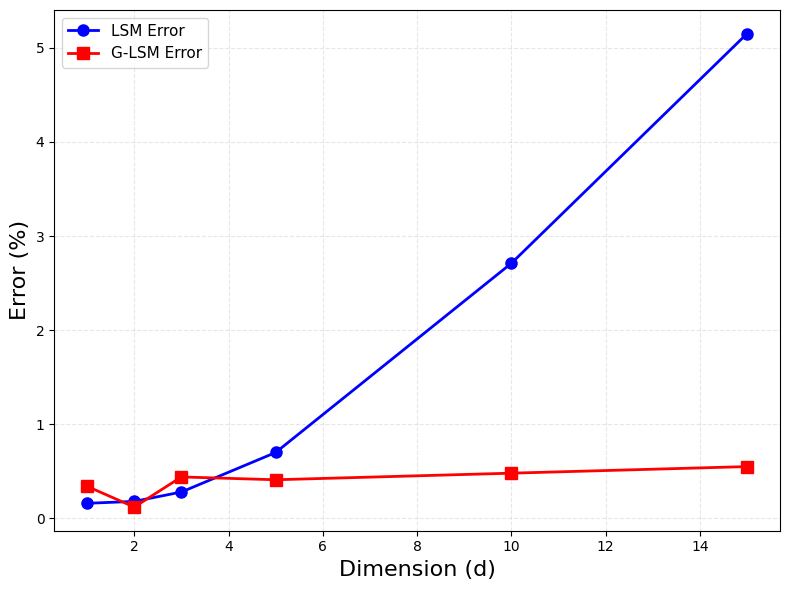

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(table_2_df['d'], table_2_df['Error'], 'o-', 
    label='LSM Error', color='blue', linewidth=2, markersize=8)
ax.plot(table_2_df['d'], table_2_df['Error G'], 's-', 
    label='G-LSM Error', color='red', linewidth=2, markersize=8)

ax.set_xlabel('Dimension (d)', fontsize=16)
ax.set_ylabel('Error (%)', fontsize=16)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("figures/table_2_plot.pdf")
plt.show()
